# CMPE 255 Assignment 1 — Part 2
## Experiment 02: NanoLlama — Small Language Model Training

### AI-Assisted Replication of Instructor Project 02

This notebook implements a compact version of the NanoLlama language model project from the instructor's `data_science_examples` repository.

The original project focuses on training a small language model and creating a chatbot experience.

For this assignment, I use a very small pretrained GPT-style model and fine-tune it on a small instruction dataset.

### Main Goals

- Prepare simple instruction-response training data
- Load a small language model
- Test the model before training
- Fine-tune the model
- Observe training loss
- Test the model after training
- Create a simple text generation demo
- Discuss the limitations of small language models

### Adaptation

Instead of training a large language model from scratch, this experiment uses a very small pretrained model so that the complete workflow can run quickly in Google Colab.

## 1. Business Understanding

Language models can generate text based on a user's input.

They can be used for applications such as:

- Question answering
- Chatbots
- Writing assistance
- Education
- Search assistance
- Customer support

The goal of this experiment is not to build a production-level chatbot.

Instead, the goal is to understand the basic workflow of adapting a small language model to a simple set of instructions.

In [4]:
!pip -q install transformers

In [5]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM

print("PyTorch version:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

PyTorch version: 2.11.0+cpu
Using device: cpu


## 2. Data Understanding

A small instruction dataset is created for this experiment.

Each training example contains:

- A user question
- An assistant response

The examples focus on basic data science concepts.

This dataset is intentionally small because the purpose of the experiment is to demonstrate the training workflow rather than build a general-purpose language model.

In [6]:
training_examples = [
    {
        "question": "What is data science?",
        "answer": "Data science uses data, programming, and statistics to understand problems and support decisions."
    },
    {
        "question": "What is machine learning?",
        "answer": "Machine learning allows computers to learn patterns from data and make predictions."
    },
    {
        "question": "What is classification?",
        "answer": "Classification predicts a category, such as yes or no."
    },
    {
        "question": "What is regression?",
        "answer": "Regression predicts a numerical value."
    },
    {
        "question": "What is clustering?",
        "answer": "Clustering groups similar observations without using known class labels."
    },
    {
        "question": "What is overfitting?",
        "answer": "Overfitting happens when a model learns the training data too closely and performs poorly on new data."
    },
    {
        "question": "What is a training set?",
        "answer": "A training set is the data used to teach a machine learning model."
    },
    {
        "question": "What is a test set?",
        "answer": "A test set is used to evaluate how well a trained model works on unseen data."
    },
    {
        "question": "What is accuracy?",
        "answer": "Accuracy is the percentage of predictions that are correct."
    },
    {
        "question": "What is precision?",
        "answer": "Precision measures how many predicted positive cases are actually positive."
    },
    {
        "question": "What is recall?",
        "answer": "Recall measures how many actual positive cases are correctly identified."
    },
    {
        "question": "What is feature engineering?",
        "answer": "Feature engineering creates useful input variables that can help a model learn."
    }
]

training_data = pd.DataFrame(
    training_examples
)

print(
    "Number of training examples:",
    len(training_data)
)

training_data

Number of training examples: 12


,question,answer
0,What is data science?,"Data science uses data, programming, and stati..."
1,What is machine learning?,Machine learning allows computers to learn pat...
2,What is classification?,"Classification predicts a category, such as ye..."
3,What is regression?,Regression predicts a numerical value.
4,What is clustering?,Clustering groups similar observations without...
5,What is overfitting?,Overfitting happens when a model learns the tr...
6,What is a training set?,A training set is the data used to teach a mac...
7,What is a test set?,A test set is used to evaluate how well a trai...
8,What is accuracy?,Accuracy is the percentage of predictions that...
9,What is precision?,Precision measures how many predicted positive...


## 3. Data Preparation

Language models are trained using text sequences.

Each question and answer is converted into a simple conversation format:

`User: question`

`Assistant: answer`

The model learns to predict the next text in this sequence.

In [7]:
formatted_texts = []

for example in training_examples:

    text = (
        "User: "
        + example["question"]
        + "\nAssistant: "
        + example["answer"]
    )

    formatted_texts.append(text)


for text in formatted_texts[:3]:

    print(text)
    print("-" * 60)

User: What is data science?
Assistant: Data science uses data, programming, and statistics to understand problems and support decisions.
------------------------------------------------------------
User: What is machine learning?
Assistant: Machine learning allows computers to learn patterns from data and make predictions.
------------------------------------------------------------
User: What is classification?
Assistant: Classification predicts a category, such as yes or no.
------------------------------------------------------------


## 4. Modeling

For this compact experiment, the model `sshleifer/tiny-gpt2` is used.

It is a very small GPT-style language model.

A small model is useful here because it allows the training process to run quickly while still demonstrating the main ideas behind language model fine-tuning.

In [8]:
model_name = "sshleifer/tiny-gpt2"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

model = AutoModelForCausalLM.from_pretrained(
    model_name
)

tokenizer.pad_token = tokenizer.eos_token

model.to(device)

print(
    "Model loaded successfully."
)

print(
    "Number of model parameters:",
    sum(
        parameter.numel()
        for parameter in model.parameters()
    )
)

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 2.51MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/29 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: sshleifer/tiny-gpt2
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
transformer.h.{0, 1}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully.
Number of model parameters: 102714


In [9]:
def generate_text(prompt, max_new_tokens=40):

    model.eval()

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():

        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_text = tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

    return generated_text

In [10]:
before_training = generate_text(
    "User: What is machine learning?\nAssistant:"
)

print("Before Training:")
print(before_training)

Before Training:
User: What is machine learning?
Assistant: stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs


In [11]:
class InstructionDataset(Dataset):

    def __init__(
        self,
        texts,
        tokenizer,
        max_length=80
    ):

        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt"
        )

    def __len__(self):

        return len(
            self.encodings["input_ids"]
        )

    def __getitem__(self, index):

        input_ids = (
            self.encodings["input_ids"][index]
        )

        attention_mask = (
            self.encodings["attention_mask"][index]
        )

        labels = input_ids.clone()

        labels[
            attention_mask == 0
        ] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }

In [12]:
dataset = InstructionDataset(
    formatted_texts,
    tokenizer
)

data_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

print(
    "Training examples:",
    len(dataset)
)

print(
    "Number of batches:",
    len(data_loader)
)

Training examples: 12
Number of batches: 3


## 5. Fine-Tuning

The model is fine-tuned using the small instruction dataset.

During training, the model tries to predict the next token in each text sequence.

The training loss measures how different the model's predictions are from the training text.

A lower training loss usually means that the model is learning the training examples more closely.

Because this is a very small demonstration dataset, only a short training process is used.

In [13]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4
)

epochs = 20

training_losses = []

model.train()

for epoch in range(epochs):

    total_loss = 0

    for batch in data_loader:

        optimizer.zero_grad()

        input_ids = (
            batch["input_ids"].to(device)
        )

        attention_mask = (
            batch["attention_mask"].to(device)
        )

        labels = (
            batch["labels"].to(device)
        )

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = (
        total_loss
        / len(data_loader)
    )

    training_losses.append(
        average_loss
    )

    print(
        f"Epoch {epoch + 1:02d} "
        f"| Loss: {average_loss:.4f}"
    )

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch 01 | Loss: 10.8252
Epoch 02 | Loss: 10.8215
Epoch 03 | Loss: 10.8191
Epoch 04 | Loss: 10.8144
Epoch 05 | Loss: 10.8121
Epoch 06 | Loss: 10.8059
Epoch 07 | Loss: 10.7977
Epoch 08 | Loss: 10.7908
Epoch 09 | Loss: 10.7842
Epoch 10 | Loss: 10.7776
Epoch 11 | Loss: 10.7715
Epoch 12 | Loss: 10.7652
Epoch 13 | Loss: 10.7586
Epoch 14 | Loss: 10.7523
Epoch 15 | Loss: 10.7461
Epoch 16 | Loss: 10.7391
Epoch 17 | Loss: 10.7328
Epoch 18 | Loss: 10.7263
Epoch 19 | Loss: 10.7193
Epoch 20 | Loss: 10.7125


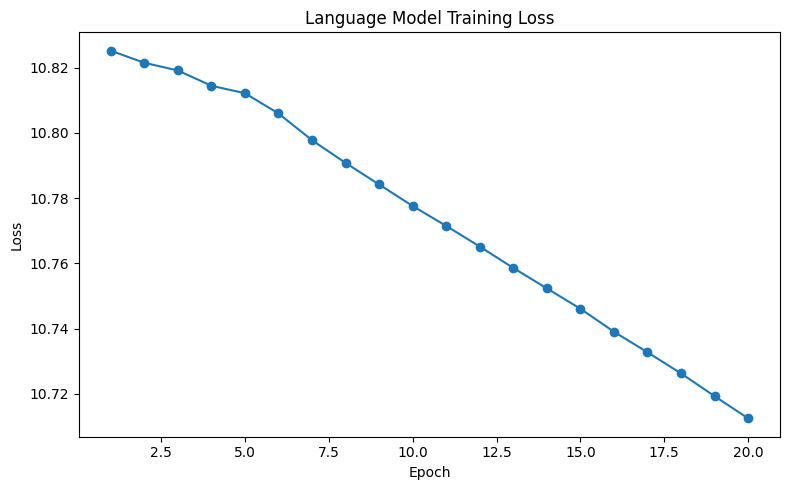

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(
        1,
        epochs + 1
    ),
    training_losses,
    marker="o"
)

plt.title(
    "Language Model Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.tight_layout()

plt.show()

In [15]:
after_training = generate_text(
    "User: What is machine learning?\nAssistant:"
)

print("After Training:")
print(after_training)

After Training:
User: What is machine learning?
Assistant: the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the


In [16]:
test_questions = [
    "What is classification?",
    "What is clustering?",
    "What is overfitting?"
]

for question in test_questions:

    prompt = (
        "User: "
        + question
        + "\nAssistant:"
    )

    result = generate_text(
        prompt
    )

    print(result)
    print("-" * 70)

User: What is classification?
Assistant: the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
----------------------------------------------------------------------
User: What is clustering?
Assistant: the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
----------------------------------------------------------------------
User: What is overfitting?
Assistant: the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
----------------------------------------------------------------------


In [17]:
def ask_model(question):

    prompt = (
        "User: "
        + question
        + "\nAssistant:"
    )

    result = generate_text(
        prompt,
        max_new_tokens=40
    )

    return result

In [18]:
ask_model(
    "What is regression?"
)

'User: What is regression?\nAssistant: the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the'

## 6. Evaluation

The training loss decreased from approximately 10.83 to 10.71 over 20 epochs.

This shows that the training process was working and that the model was learning patterns from the small training dataset.

However, the generated text did not become useful.

Before fine-tuning, the model repeatedly generated the word "stairs".

After fine-tuning, the model mainly repeated the word "the".

The same behavior appeared when testing questions about classification, clustering, and overfitting.

This experiment demonstrates an important lesson:

**Lower training loss does not automatically mean better text generation quality.**

The model used in this experiment is extremely small, and the training dataset contains only 12 examples. This is not enough to produce a useful question-answering model.

Language model evaluation therefore requires both numerical measures and direct inspection of the generated responses.

In [19]:
comparison = pd.DataFrame({
    "Stage": [
        "Before Fine-Tuning",
        "After Fine-Tuning"
    ],
    "Observed Behavior": [
        "Repeated the word 'stairs'",
        "Repeated the word 'the'"
    ],
    "Useful Answer": [
        "No",
        "No"
    ]
})

comparison

,Stage,Observed Behavior,Useful Answer
0,Before Fine-Tuning,Repeated the word 'stairs',No
1,After Fine-Tuning,Repeated the word 'the',No


## 7. Limitations

This experiment is a small educational demonstration rather than a production language model.

Important limitations include:

- The model is extremely small.
- The training dataset contains only 12 examples.
- The training data covers only a few basic data science questions.
- Training for 20 epochs is still very limited compared with real language model training.
- The model produced repetitive text instead of useful answers.
- A lower training loss did not result in good text generation.
- The model does not have the size, data, or training needed for a useful chatbot.

A stronger system would require a better base model, much more training data, more computing resources, and more complete evaluation.

## 8. Conclusion

This experiment implemented a compact small language model training workflow.

The project included:

- Instruction-response data preparation
- Tokenization
- Loading a small pretrained language model
- Testing before fine-tuning
- Fine-tuning for 20 epochs
- Training loss analysis
- Testing after fine-tuning
- A simple text generation function

Training loss decreased from approximately 10.83 to 10.71.

However, the generated responses remained poor. Before training, the model repeated the word "stairs", while after training it mainly repeated the word "the".

This result shows that successful training cannot be measured by training loss alone.

Model output quality must also be evaluated directly.

The experiment also demonstrates why useful language models require sufficient model size, training data, computing resources, and careful evaluation.

Although this compact model did not become a useful chatbot, the experiment successfully demonstrates the main steps and challenges of small language model fine-tuning.